# PhoBERT Fine-tuning trên bộ dữ liệu ViHSD
> **Môi trường:** Kaggle Notebook — GPU T4 / P100  
> **Model:** `vinai/phobert-base` (pre-trained 20GB tiếng Việt)  
> **Task:** Vietnamese Hate Speech Detection — 3 nhãn: CLEAN · OFFENSIVE · HATE  
> **Kỳ vọng:** Macro F1 ~0.78–0.82

---
## Pipeline
```
Raw text → PhoBERT Tokenizer (BPE) → PhoBERT Encoder (12 layers)
        → [CLS] vector → Dropout → Linear → Softmax (3 classes)
```

## 1. Cài đặt thư viện

In [37]:
!pip install transformers datasets sentencepiece -q

## 2. Import & kiểm tra GPU

In [38]:
import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 3. Hyperparameters

In [39]:
# ── Config ───────────────────────────────────────────────────────
MODEL_NAME   = 'vinai/phobert-base'   # hoặc 'vinai/phobert-large'
MAX_LEN      = 128     # PhoBERT tối đa 256; 128 đủ cho tweets/comments
BATCH_SIZE   = 32      # T4: 32 ổn; P100: thử 16 nếu OOM
NUM_EPOCHS   = 5       # PhoBERT hội tụ nhanh, 3–5 epoch là đủ
LR           = 2e-5    # learning rate chuẩn cho fine-tune BERT
WARMUP_RATIO = 0.1     # 10% steps đầu warm up
DROPOUT      = 0.3
NUM_CLASSES  = 3
LABEL_MAP    = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
PATIENCE     = 3
# ─────────────────────────────────────────────────────────────────

## 4. Tải dữ liệu ViHSD

In [40]:
train_df = pd.read_csv ('/kaggle/input/datasets/mnhtndev/vihsd-dataphobert/train.csv')
val_df   = pd.read_csv ('/kaggle/input/datasets/mnhtndev/vihsd-dataphobert/dev.csv')
test_df  = pd.read_csv ('/kaggle/input/datasets/mnhtndev/vihsd-dataphobert/test.csv')

# Kiểm tra tên cột label
print(train_df.columns.tolist())
print(train_df.head(3))
print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# Phân phối nhãn
print('\nPhân phối train:')
print(train_df['label_id'].value_counts().sort_index())

['free_text', 'label_id']
                                           free_text  label_id
0  Em được làm fan cứng luôn rồi nè ❤️ reaction q...         0
1  Đúng là bọn mắt híp lò xo thụt :))) bên việt n...         2
2           Đậu Văn Cường giờ giống thằng sida hơn à         0

Train: 24,048 | Val: 2,672 | Test: 6,680

Phân phối train:
label_id
0    19886
1     1606
2     2556
Name: count, dtype: int64


In [41]:
# Tự động xác định tên cột
text_col  = 'free_text' if 'free_text' in train_df.columns else 'text'
label_col = 'label_id'
print(f'Text column : {text_col}')
print(f'Label column: {label_col}')

Text column : free_text
Label column: label_id


## 5. Tiền xử lý & Tokenizer

In [42]:
def clean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r'http\S+|www\.\S+', '', text)   # xóa URL
    text = re.sub(r'@\w+', '', text)                # xóa mention
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Load PhoBERT tokenizer
print('Loading PhoBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,}')

# Test tokenize
sample = 'Mày là đồ ngu! Xem tại https://example.com'
cleaned = clean_text(sample)
tokens  = tokenizer.tokenize(cleaned)
print(f'\nInput  : {sample}')
print(f'Cleaned: {cleaned}')
print(f'Tokens : {tokens}')

Loading PhoBERT tokenizer...
Vocab size: 64,000

Input  : Mày là đồ ngu! Xem tại https://example.com
Cleaned: Mày là đồ ngu! Xem tại
Tokens : ['Mày', 'là', 'đồ', 'ngu@@', '!', 'Xem', 'tại']


## 6. Dataset class

In [43]:
class ViHSDDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN,
                 text_col='free_text', label_col='label_id'):
        self.texts     = df[text_col].apply(clean_text).tolist()
        self.labels    = df[label_col].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = ViHSDDataset(train_df, tokenizer, text_col=text_col, label_col=label_col)
val_dataset   = ViHSDDataset(val_df,   tokenizer, text_col=text_col, label_col=label_col)
test_dataset  = ViHSDDataset(test_df,  tokenizer, text_col=text_col, label_col=label_col)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 752 | Val: 84 | Test: 209


## 7. Mô hình PhoBERT + Classifier

In [44]:
class PhoBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=DROPOUT):
        super().__init__()
        # ── PhoBERT backbone ─────────────────────────────────────
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size  # 768 cho base

        # ── Classifier head ──────────────────────────────────────
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )
        # Lấy vector [CLS] (token đầu tiên)
        cls_output = outputs.last_hidden_state[:, 0, :]   # (B, 768)
        cls_output = self.dropout(cls_output)
        logits     = self.fc(cls_output)                  # (B, 3)
        return logits


print('Loading PhoBERT model...')
model = PhoBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tổng tham số      : {total_params:,}')
print(f'Tham số trainable : {trainable_params:,}')

Loading PhoBERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tổng tham số      : 135,000,579
Tham số trainable : 135,000,579


## 8. Loss, Optimizer & Scheduler

In [45]:
# Class weights để xử lý mất cân bằng nhãn
label_counts = train_df[label_col].value_counts().sort_index().values
class_weights = torch.tensor(
    len(train_df) / (NUM_CLASSES * label_counts), dtype=torch.float32
).to(DEVICE)
print('Class weights:', class_weights.cpu().numpy().round(3))

criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer: phân biệt LR cho BERT backbone vs classifier head ─
optimizer = optim.AdamW([
    {'params': model.bert.parameters(), 'lr': LR},
    {'params': model.fc.parameters(),   'lr': LR * 10}  # head học nhanh hơn
], weight_decay=0.01)

# ── Scheduler: linear warmup → linear decay ──────────────────────
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Class weights: [0.403 4.991 3.136]
Total steps: 3760 | Warmup steps: 376


## 9. Training loop

In [46]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss    += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(1)

        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total_samples, total_correct / total_samples, macro_f1


# ── Training ─────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_f1, best_epoch, patience_counter = 0, 0, 0

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val F1':>6} | {'LR':>8} | {'Time':>6}")
print('-' * 88)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc             = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    vl_loss, vl_acc, vl_f1     = evaluate(model, val_loader, criterion)
    elapsed = time.time() - t0
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    flag = ''
    if vl_f1 > best_f1:
        best_f1, best_epoch = vl_f1, epoch
        torch.save(model.state_dict(), 'best_phobert_vihsd.pt')
        patience_counter = 0
        flag = ' ✓ saved'
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping tại epoch {epoch}')
            break

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>6.4f} | {current_lr:>8.2e} | {elapsed:>5.1f}s{flag}')

print(f'\nBest Val F1 = {best_f1:.4f} tại epoch {best_epoch}')

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1 |       LR |   Time
----------------------------------------------------------------------------------------
     1 |     0.9183 |    0.6379 |   0.8088 |  0.7900 | 0.5988 | 1.78e-05 | 499.0s ✓ saved
     2 |     0.6823 |    0.7849 |   0.7293 |  0.7178 | 0.5688 | 1.33e-05 | 511.7s
     3 |     0.5333 |    0.8330 |   0.8617 |  0.8353 | 0.6572 | 8.89e-06 | 511.8s ✓ saved
     4 |     0.4206 |    0.8714 |   0.9092 |  0.8114 | 0.6352 | 4.44e-06 | 512.0s
     5 |     0.3397 |    0.8954 |   0.9970 |  0.8204 | 0.6413 | 0.00e+00 | 511.7s

Best Val F1 = 0.6572 tại epoch 3


## 10. Visualize training

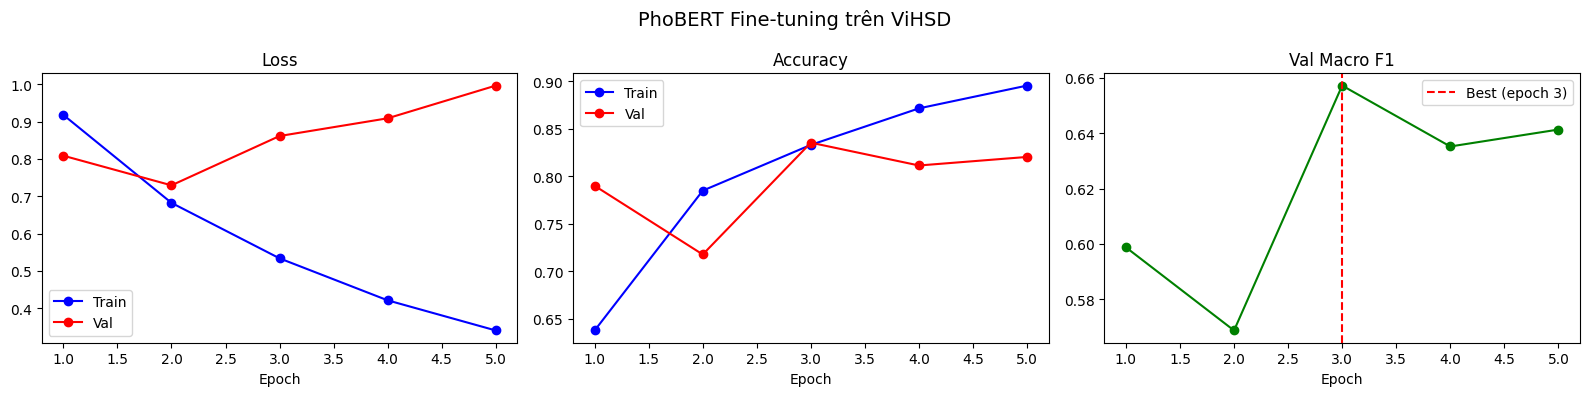

In [47]:
n = len(history['train_loss'])
epochs_range = range(1, n + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], 'g-o')
axes[2].axvline(best_epoch, color='red', linestyle='--', label=f'Best (epoch {best_epoch})')
axes[2].set_title('Val Macro F1'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.suptitle('PhoBERT Fine-tuning trên ViHSD', fontsize=14)
plt.tight_layout()
plt.savefig('phobert_training_curves.png', dpi=150)
plt.show()

## 11. Đánh giá trên tập Test

In [48]:
# Load best model
model.load_state_dict(torch.load('best_phobert_vihsd.pt', map_location=DEVICE))

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        logits = model(input_ids, attention_mask)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(model, test_loader)

print('=' * 60)
print('Classification Report trên Test Set')
print('=' * 60)
print(classification_report(
    y_true, y_pred,
    target_names=['CLEAN', 'OFFENSIVE', 'HATE'],
    digits=4
))

Classification Report trên Test Set
              precision    recall  f1-score   support

       CLEAN     0.9499    0.8846    0.9161      5548
   OFFENSIVE     0.3534    0.5023    0.4149       444
        HATE     0.5045    0.6468    0.5669       688

    accuracy                         0.8347      6680
   macro avg     0.6026    0.6779    0.6326      6680
weighted avg     0.8644    0.8347    0.8468      6680



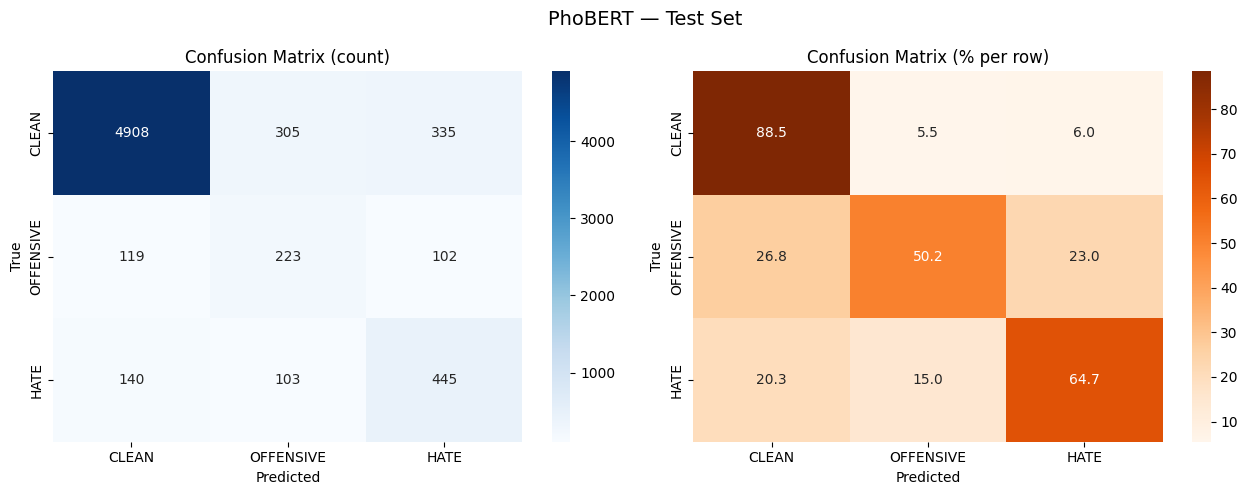

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
labels = ['CLEAN', 'OFFENSIVE', 'HATE']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm,     annot=True, fmt='d',   cmap='Blues',   ax=axes[0], xticklabels=labels, yticklabels=labels)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix (count)')
axes[1].set_title('Confusion Matrix (% per row)')
for ax in axes:
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('PhoBERT — Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('phobert_confusion_matrix.png', dpi=150)
plt.show()

## 12. Inference — Dự đoán câu mới

In [50]:
@torch.no_grad()
def predict(texts: list) -> list:
    model.eval()
    results = []
    for text in texts:
        enc = tokenizer(
            clean_text(text),
            max_length     = MAX_LEN,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        input_ids      = enc['input_ids'].to(DEVICE)
        attention_mask = enc['attention_mask'].to(DEVICE)
        logits = model(input_ids, attention_mask)
        probs  = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        label_id = probs.argmax()
        results.append({
            'text'      : text,
            'prediction': LABEL_MAP[label_id],
            'probs'     : {LABEL_MAP[i]: round(float(p), 4) for i, p in enumerate(probs)}
        })
    return results


demo_texts = [
    'Hôm nay trời đẹp quá, đi chơi thôi!',
    'Mày ngu vãi, làm cái gì cũng hỏng hết!',
    'Tụi nó toàn là rác rưởi của xã hội, cần phải loại bỏ!',
    'Bộ phim hay lắm, mình xem đi xem lại mấy lần rồi.',
    'Đồ súc vật, mày không xứng đáng sống trên đời này!',
    "tao cảm ơn mày nhiều lắm"
]

preds = predict(demo_texts)
print(f"{'Text':<55} | {'Nhãn':^12} | Xác suất")
print('-' * 105)
for r in preds:
    short    = r['text'][:52] + '...' if len(r['text']) > 52 else r['text']
    prob_str = '  '.join([f"{k}: {v:.3f}" for k, v in r['probs'].items()])
    print(f"{short:<55} | {r['prediction']:^12} | {prob_str}")

Text                                                    |     Nhãn     | Xác suất
---------------------------------------------------------------------------------------------------------
Hôm nay trời đẹp quá, đi chơi thôi!                     |    CLEAN     | CLEAN: 0.987  OFFENSIVE: 0.009  HATE: 0.004
Mày ngu vãi, làm cái gì cũng hỏng hết!                  |     HATE     | CLEAN: 0.005  OFFENSIVE: 0.017  HATE: 0.979
Tụi nó toàn là rác rưởi của xã hội, cần phải loại bỏ... |     HATE     | CLEAN: 0.026  OFFENSIVE: 0.050  HATE: 0.923
Bộ phim hay lắm, mình xem đi xem lại mấy lần rồi.       |    CLEAN     | CLEAN: 0.993  OFFENSIVE: 0.004  HATE: 0.003
Đồ súc vật, mày không xứng đáng sống trên đời này!      |     HATE     | CLEAN: 0.008  OFFENSIVE: 0.012  HATE: 0.981
tao cảm ơn mày nhiều lắm                                |    CLEAN     | CLEAN: 0.990  OFFENSIVE: 0.003  HATE: 0.007


## 13. Lưu model

In [52]:
import json

# Lưu config
config = {
    'model_name'  : MODEL_NAME,
    'max_len'     : MAX_LEN,
    'num_classes' : NUM_CLASSES,
    'label_map'   : LABEL_MAP,
    'best_epoch'  : best_epoch,
    'best_val_f1' : best_f1,
    'test_macro_f1': float(f1_score(y_true, y_pred, average='macro'))
}
with open('phobert_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('Đã lưu:')
print(' - best_phobert_vihsd.pt      (model weights)')
print(' - phobert_config.json        (config & results)')
print(' - phobert_training_curves.png')
print(' - phobert_confusion_matrix.png')
print(' - model_comparison.png')
print(f'\nTest Macro F1 = {config["test_macro_f1"]:.4f}')

Đã lưu:
 - best_phobert_vihsd.pt      (model weights)
 - phobert_config.json        (config & results)
 - phobert_training_curves.png
 - phobert_confusion_matrix.png
 - model_comparison.png

Test Macro F1 = 0.6326
